<h1>Borrador de Arturo </h1>

In [7]:
%load_ext autoreload
%autoreload 2
import sys
import os 
import networkx as nx 
from matplotlib import pyplot as plt
#Codigo para importar grafos y logica pues estan en una carpeta afuera
ruta_proyecto = r"C:\Users\Arturo\Documents\Proyecto LCC\proyecto-logica-G5"
# Si no está en el sistema se agrega.
if ruta_proyecto not in sys.path:
    sys.path.append(ruta_proyecto)

# Como ya está en el sistema ya se podría importar
try:
    from logica import*   
    print(" Módulo lógica cargado exitosamente")
except ModuleNotFoundError:
    print(" No se encontró el archivo. Revisa que el nombre sea correcto.") 
try:
    from grafos import*
    print(" Módulo grafos cargado exitosamente")
except ModuleNotFoundError:
    print(" No se encontró el archivo. Revisa que el nombre sea correcto.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
 Módulo lógica cargado exitosamente
 Módulo grafos cargado exitosamente


In [8]:
g = Grafos()

<h2>REGLA 1</h2>

In [9]:
regla1 = g.regla1()

CPU times: total: 0 ns
Wall time: 5.96 μs


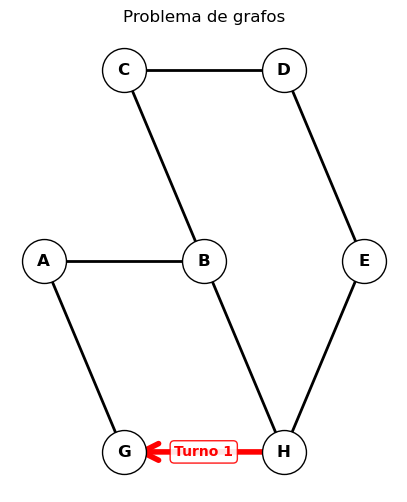

In [10]:
%time
formula1 = inorder_to_tree(regla1)  
I = formula1.SATtableaux_backtracking()
g.visualizar_grafo(I)


<h2>REGLA 2</h2>

In [11]:
b_conec = [(a,b) for (a,b) in g.recorridos if b=='B' ]   
print(b_conec)

formula_final = ""
t = 7  

for recorrido in b_conec: 
    movimiento_actual = recorrido  # Ya es una tupla (u, v)
    
    # Filtramos los otros movimientos
    otros_movimientos = [m for m in g.recorridos if m != movimiento_actual]    
    
    formula1 = ""
    inicial = True 
    
    for mov in otros_movimientos: 
        if inicial: 
            formula1 = "-" + g.To.ravel([mov, t]) 
            inicial = False 
        else: 
            formula1 = "(" + formula1 + "Y-" + g.To.ravel([mov, t]) + ")" 
    
    bloque_actual = "(" + g.To.ravel([movimiento_actual, t]) + "Y" + formula1 + ")" 
    
    if formula_final == "":
        formula_final = bloque_actual 
    else:
        formula_final = "(" + formula_final + "O" + bloque_actual + ")"

print(formula_final)

[('H', 'B'), ('A', 'B'), ('C', 'B')]
(((ŲY((((((((((((((-ŰY-ű)Y-ų)Y-Ŵ)Y-ŵ)Y-Ŷ)Y-ŷ)Y-Ÿ)Y-Ź)Y-ź)Y-Ż)Y-ż)Y-Ž)Y-ž)Y-ſ))O(ŸY((((((((((((((-ŰY-ű)Y-Ų)Y-ų)Y-Ŵ)Y-ŵ)Y-Ŷ)Y-ŷ)Y-Ź)Y-ź)Y-Ż)Y-ż)Y-Ž)Y-ž)Y-ſ)))O(ŻY((((((((((((((-ŰY-ű)Y-Ų)Y-ų)Y-Ŵ)Y-ŵ)Y-Ŷ)Y-ŷ)Y-Ÿ)Y-Ź)Y-ź)Y-ż)Y-Ž)Y-ž)Y-ſ)))


In [12]:
formula1 = inorder_to_tree(formula_final) 

logica.Binario

In [18]:
I = formula1.SATtableaux_anchura() 


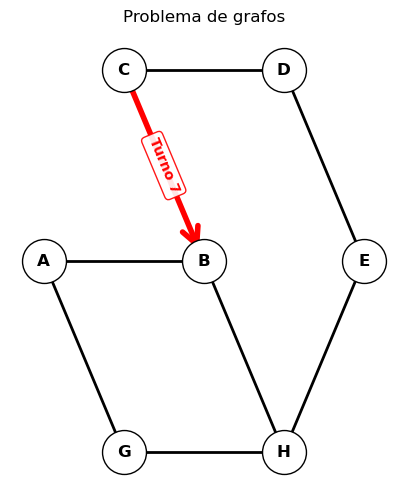

In [19]:
g.visualizar_grafo(I)